<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning Foundations & Optimization – MNIST Classification using MLP**
# Objective:
To analyze the impact of Weight Initialization strategies (Xavier vs. He) and Optimization algorithms (SGD vs. Adam) on training stability and convergence speed.


### Step 1: Setup Environment
This step imports necessary libraries like TensorFlow for deep learning, NumPy for numerical operations, and Matplotlib for plotting. It also sets random seeds to ensure reproducibility of the experiment results.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("Environment setup complete.")

Environment setup complete.


### Step 2: Load Dataset

This step loads the MNIST dataset, which consists of handwritten digits, directly from Keras. It then splits the dataset into training and testing sets for model development and evaluation.

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28), (60000,)
Testing data shape: (10000, 28, 28), (10000,)


### Step 3: Data Preprocessing
This step prepares the raw MNIST image data for neural network training. It normalizes pixel values to a [0, 1] range, flattens each 28x28 image into a 784-element vector, and converts the integer labels into one-hot encoded vectors.

In [3]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten images from 28x28 to 784
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Preprocessed training data shape: {X_train.shape}, {y_train.shape}")
print(f"Preprocessed testing data shape: {X_test.shape}, {y_test.shape}")

Preprocessed training data shape: (60000, 784), (60000, 10)
Preprocessed testing data shape: (10000, 784), (10000, 10)


### Step 4: Model Architecture Function
This step defines a function `build_model` that creates a Multi-Layer Perceptron (MLP) for MNIST classification. The function takes `initializer` and `optimizer` as arguments, allowing for dynamic construction of models with different initialization strategies and optimization algorithms.

In [4]:
def build_model(initializer, optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer),
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer=initializer),
        tf.keras.layers.Dense(10, activation='softmax', kernel_initializer=initializer)
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print("Model building function defined.")

Model building function defined.


### Step 5: Experiment 1 – Weight Initialization Comparison
This step trains three different MLP models, each using a distinct weight initialization strategy: `RandomNormal`, `GlorotUniform` (Xavier), and `HeNormal`. The optimizer is fixed to `Adam` for all models, and they are trained for the same number of epochs and batch size to isolate the effect of initialization.

In [5]:
initializers = {
    'RandomNormal': tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=42),
    'GlorotUniform': tf.keras.initializers.GlorotUniform(seed=42),
    'HeNormal': tf.keras.initializers.HeNormal(seed=42)
}

epochs = 10
batch_size = 32

histories_init = {}
models_init = {}

for name, initializer in initializers.items():
    print(f"\nTraining model with {name} initialization...")
    model = build_model(initializer, 'adam')
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)
    histories_init[name] = history.history
    models_init[name] = model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

print("Weight initialization experiment complete.")


Training model with RandomNormal initialization...
RandomNormal - Test Loss: 0.1348, Test Accuracy: 0.9695

Training model with GlorotUniform initialization...
GlorotUniform - Test Loss: 0.1212, Test Accuracy: 0.9733

Training model with HeNormal initialization...
HeNormal - Test Loss: 0.1511, Test Accuracy: 0.9679
Weight initialization experiment complete.


### Step 6: Plot Comparison (Initialization)
This step generates plots to visually compare the performance of different weight initializers. It displays training loss and training accuracy over epochs for `RandomNormal`, `GlorotUniform`, and `HeNormal` initializations on the same graph, allowing for easy comparison of convergence and performance.

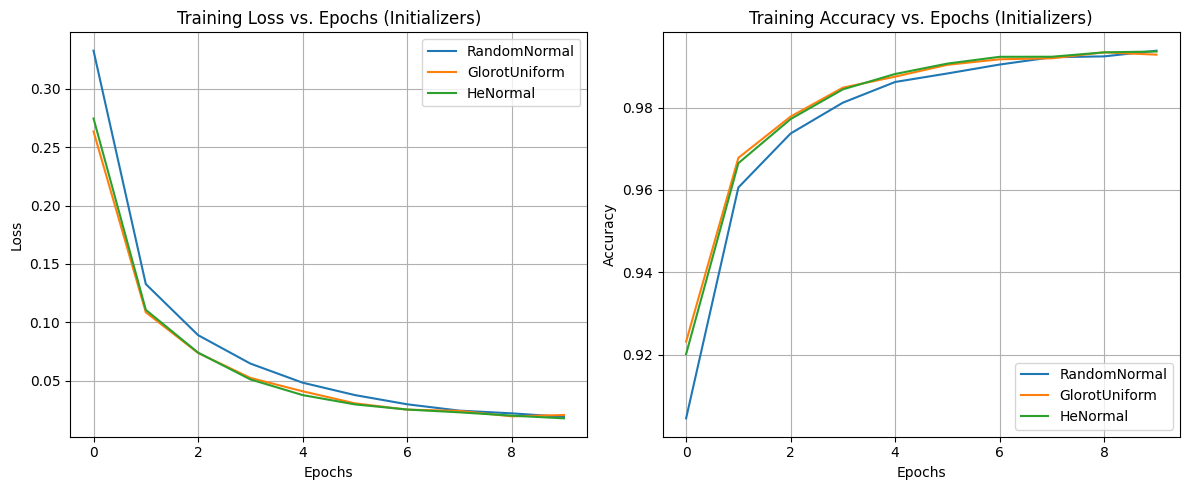

Initialization comparison plots generated.


In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, history in histories_init.items():
    plt.plot(history['loss'], label=name)
plt.title('Training Loss vs. Epochs (Initializers)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, history in histories_init.items():
    plt.plot(history['accuracy'], label=name)
plt.title('Training Accuracy vs. Epochs (Initializers)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Initialization comparison plots generated.")

### Step 7: Experiment 2 – Optimizer Comparison
This step investigates the impact of different optimization algorithms on model training. Using the `HeNormal` initializer (identified as potentially best from the previous experiment), two models are trained: one with `SGD` optimizer and another with `Adam` optimizer. All other parameters are kept consistent to isolate the optimizer's effect.

In [7]:
optimizers = {
    'SGD': 'sgd',
    'Adam': 'adam'
}

best_initializer = tf.keras.initializers.HeNormal(seed=42)

histories_opt = {}
models_opt = {}

for name, optimizer in optimizers.items():
    print(f"\nTraining model with {name} optimizer...")
    model = build_model(best_initializer, optimizer)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)
    histories_opt[name] = history.history
    models_opt[name] = model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

print("Optimizer comparison experiment complete.")


Training model with SGD optimizer...
SGD - Test Loss: 0.1322, Test Accuracy: 0.9620

Training model with Adam optimizer...
Adam - Test Loss: 0.1511, Test Accuracy: 0.9679
Optimizer comparison experiment complete.


### Step 8: Plot Comparison (Optimizers)
This step creates plots to visually compare the training performance of `SGD` and `Adam` optimizers. It shows training loss and accuracy over epochs for both optimizers on the same graph, facilitating a direct comparison of their effectiveness and convergence characteristics.

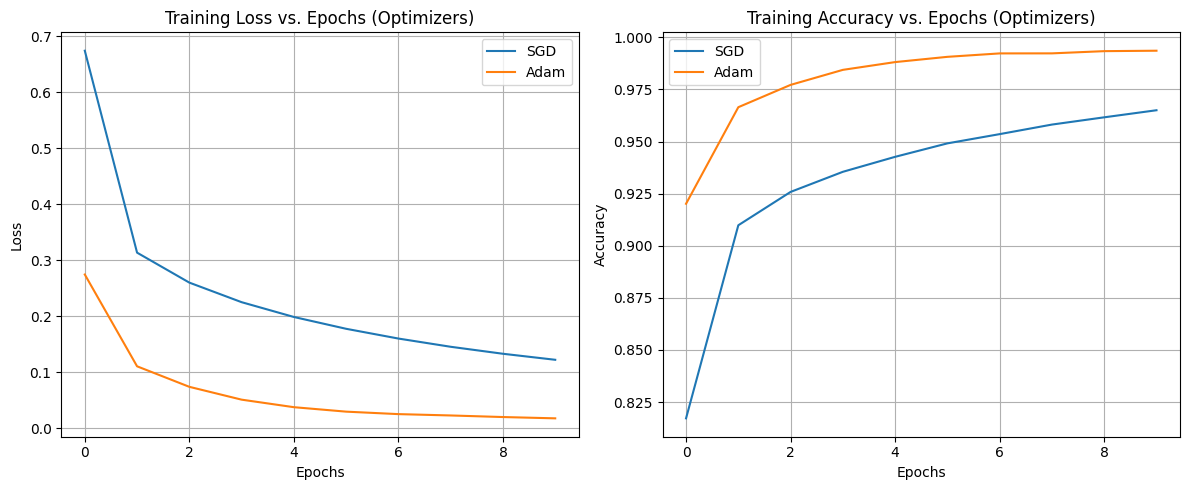

Optimizer comparison plots generated.


In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, history in histories_opt.items():
    plt.plot(history['loss'], label=name)
plt.title('Training Loss vs. Epochs (Optimizers)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, history in histories_opt.items():
    plt.plot(history['accuracy'], label=name)
plt.title('Training Accuracy vs. Epochs (Optimizers)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Optimizer comparison plots generated.")